# Training HF NN

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, kCrossValSingle
from time import perf_counter
import pandas
import os
seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
#########################     TRAIN SET      ##########################
mu_train_HF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/mu_train_HF_young_15.txt")[:,0]
permutation = np.random.permutation(len(mu_train_HF))
mu_train_HF=mu_train_HF[permutation][0:5]
U_hf_train = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young/Uhf_train_young_15.txt")
U_hf_train=U_hf_train[permutation][0:5]
Nhf = np.size(mu_train_HF)  #number of low-fidelity data to TRAIN the NN
NepoHF = 3000  

In [3]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/mu_test_young.txt")[:,0]
N_test = np.size(mu_test)

U_hf_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young/Uhf_test_young.txt")
#U_lf_test = U_lf_test_full[:,m]

In [4]:
########################     NORMALIZATION  #########################
#Input
mu_max = np.max(mu_test)
mu_min = np.min(mu_test)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_HF_norm = (mu_train_HF - mu_min) / (mu_max - mu_min)

#Tranformation 
U_hf_train = np.exp(U_hf_train*100)*1e-6
U_hf_test = np.exp(U_hf_test*100)*1e-6
#Output
#hfmean = np.mean(U_hf_test)

#U_hf_train = U_hf_train - hfmean
#U_hf_test = U_hf_test - hfmean
U_tr_max=np.max(U_hf_train)
U_tr_min=np.min(U_hf_train)
U_te_max=np.max(U_hf_test)
U_te_min=np.min(U_hf_test)

U_hf_train=(U_hf_train-U_tr_min)/(U_tr_max-U_tr_min)
U_hf_test=(U_hf_test-U_te_min)/(U_te_max-U_te_min)

start = perf_counter()
#########
mu_final = np.vstack((mu_train_HF_norm))#.transpose() # <- TRAINING INPUT for the second NN: NN_HF
########

In [5]:
##########################       NN_HF     ##########################
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 2
name = 'LF'   # I leave the same NN,  even if we use HF data instead of LF 
K.clear_session()
bayes_trials = Trials()
#opt_list = ['Adam','Adamax']
#kernel_list = ['uniform','glorot_uniform']
#aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
#space = {
#    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(64),2),
#     'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(100)),
#     'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
#     'kernel_init': hp.choice('kernel_init',kernel_list),
#     'opt' : hp.choice('opt',opt_list)}


opt_list = ['Adam']
kernel_list = ['uniform']
aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
space = {
    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(64),2),
     'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(100)),
     'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
     'kernel_init': hp.choice('kernel_init',kernel_list),
     'opt' : hp.choice('opt',opt_list)}


def objective(params):
    K.clear_session()
    CVres = kCrossValSingle(Nhf,NepoHF,mu_final, U_hf_train,params,name)
    return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

best_params = fmin(fn = objective,
                   space = space,
                   algo = tpe.suggest,
                   max_evals = MAX_EVAL,
                   trials = bayes_trials)

transfBestparam(best_params,aux_dic)
print(best_params)

  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 117ms/step

1/1 [==============================] - 0s 34ms/step 

1/1 [==============================] - 0s 17ms/step 

1/1 [==============================] - 0s 17ms/step 

1/1 [==============================] - 0s 17ms/step 

1/1 [==============================] - 0s 77ms/step                             

1/1 [==============================] - 0s 31ms/step                             

1/1 [==============================] - 0s 33ms/step                             

1/1 [==============================] - 0s 31ms/step                             

1/1 [==============================] - 0s 28ms/step                             

100%|██████████| 2/2 [02:10<00:00, 65.35s/trial, best loss: 0.022931717375043428]
{'kernel_init': 'uniform', 'l2weight': 0.12402065976324562, 'lr': 0.0013451929655146368, 'nodes': 4.0, 'opt': 'Adam'}


In [6]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()

finalModel = getModel(best_params,name) #final model chosen according to the best paramters
hist = finalModel.fit(mu_train_HF_norm, U_hf_train, validation_data=(mu_test_norm, U_hf_test),epochs=NepoHF,batch_size=Nhf,verbose=0, validation_freq = 20)

UHF = finalModel.predict(mu_test_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nHF Model:')

elapsed2 = stop - start2
print('Elapsed time: ', elapsed2)
print('\nHF Model:')

test_mse = np.mean(np.square(U_hf_test - UHF[:,0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_hf_test - UHF[:,0])) / np.sum(np.square(U_hf_test - np.mean(U_hf_test)))
print(f"R^2: {r2_HF}")

#print('Number of basis functions: ', int(Nlf_models[m]))
#print('Number of LF data: ', n_LF)

4/4 [==============================] - 0s 2ms/step
Elapsed time:  153.47195050003938

HF Model:
Elapsed time:  22.700300200027414

HF Model:
Test MSE: 0.0015823926641707908
R^2: 0.9793395066023348


4/4 [==============================] - 0s 4ms/step


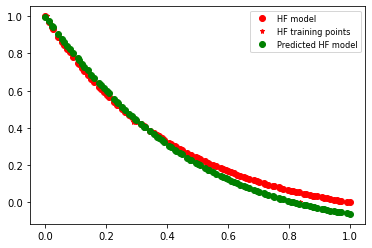

In [7]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(mu_test_norm, U_hf_test,'ro', linewidth = 1.5, label = 'HF model')
plt.plot(mu_train_HF_norm, U_hf_train,'r*', markersize = 5, label = 'HF training points')
plt.plot(mu_test_norm, finalModel.predict(mu_test_norm),'go', linewidth = 3, label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()

In [9]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs('Output_NNHF_rel_no_noise')

R2_HF=pandas.DataFrame({'R2_HF': [r2_HF]})
#R2_LF=pandas.DataFrame({'R2_LF': [r2_LF]})
#MSE_test_LF=pandas.DataFrame({'MSE_test_LF': [test_mse_LF]})
MSE_test_HF=pandas.DataFrame({'MSE_test_HF': [test_mse]})


#R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv('./Output_NNHF_rel_no_noise/test_mse.txt', header = True, index = False, sep = '\t', mode = 'a')
R2_HF.to_csv('./Output_NNHF_rel_no_noise/r2_LF_lhs.txt', header=True, index=False, sep='\t', mode='a')
#MSE_test_LF.to_csv('./Output_NNHF/mse_LF_lhs.txt', header = True, index = False, sep = '\t', mode = 'a')